In [92]:
import pandas as pd
import glob
import os
import re
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import matplotlib.colors as mcolors

In [ ]:
def get_v600_status(vcf_dir="filtered_vcfs"):
    """Detect BRAF V600E/K/R from filtered VCFs using coordinate-based logic,
    sorting results by clinical timepoint."""

    timepoint_map = {
        "PRE": "Baseline",
        "ED1": "Week 1",
        "ED2": "Week 2",
        "CLND": "Week 6",
        "PRO": "Progressed",
        "PROG": "Progressed",
    }
    tp_order = ["Baseline", "Week 1", "Week 2", "Week 6", "Progressed"]

    ## CALLING STRAIGHT FROM RSID ALONE wont be enough 
    # BRAF V600 locus on GRCh38 (forward strand)
    V600_CHROM = "chr7"
    V600_POS_336 = 140753336  # shared by V600E and first base of V600K/R
    V600_POS_337 = 140753337  # second base of V600K/R

    results = []

    for vcf_path in sorted(glob.glob(os.path.join(vcf_dir, "*.filtered.vcf"))):
        filename = os.path.basename(vcf_path)

        # Extract melpin and timepoint from filename
        timepoint = "Unknown"
        patient_id = filename
        match = re.match(r"^(\d+)(CLND|PROG|PRO|PRE|ED1|ED2)", filename, re.IGNORECASE)
        if match:
            patient_id = match.group(1)
            tp_key = match.group(2).upper()
            timepoint = timepoint_map.get(tp_key, "Unknown")

        # Collect all variants at the V600 locus
        v600_variants = {}  # pos to fields list
        with open(vcf_path) as f:
            for line in f:
                if line.startswith("#"):
                    continue
                fields = line.strip().split("\t")
                chrom = fields[0]
                pos = int(fields[1])
                filt = fields[6]
                # Only consider PASS variants at the V600 locus
                if chrom == V600_CHROM and pos in (V600_POS_336, V600_POS_337) and filt == "PASS":
                    v600_variants[pos] = fields
        
        ### we will have to account for edge cases 
        if V600_POS_336 in v600_variants:
            fields_336 = v600_variants[V600_POS_336]
            ref_336 = fields_336[3]
            alt_336 = fields_336[4]

            # Case 1: MNV record (HaplotypeCaller emitted merged dinucleotide)
            if ref_336 == "AC":
                if alt_336 == "TT":
                    v600_type = "V600K"
                elif alt_336 == "CT":
                    v600_type = "V600R"
                else:
                    v600_type = f"V600_unknown({ref_336}>{alt_336})"

            # Case 2: Single-base REF at 336 - check if 337 also has a variant
            elif ref_336 == "A":
                if V600_POS_337 in v600_variants:
                    # Two adjacent split SNVs - reconstruct the dinucleotide
                    fields_337 = v600_variants[V600_POS_337]
                    alt_337 = fields_337[4]
                    combined_alt = alt_336 + alt_337

                    if combined_alt == "TT":
                        v600_type = "V600K"
                    elif combined_alt == "CT":
                        v600_type = "V600R"
                    else:
                        v600_type = f"V600_unknown(AC>{combined_alt})"

                    # Overwrite so output REF/ALT reflect the actual event
                    ref_336 = "AC"
                    alt_336 = combined_alt

                elif alt_336 == "T":
                    # Only 336 mutated, no variant at 337 - V600E
                    v600_type = "V600E"
                else:
                    v600_type = f"V600_unknown({ref_336}>{alt_336})"
            else:
                v600_type = f"V600_unknown({ref_336}>{alt_336})"

            # Extract AF from the primary position
            info = fields_336[7] if ref_336 != "AC" else v600_variants[V600_POS_336][7]
            af_match = re.search(r"AF=([0-9.]+)", info)
            af = float(af_match.group(1)) if af_match else None

            results.append({
                "PATIENT": patient_id,
                "TIMEPOINT": timepoint,
                "REF": ref_336,
                "ALT": alt_336,
                "V600_TYPE": v600_type,
                "AF": af,
                "QUAL": fields_336[5],
                "FILTER": fields_336[6],
                "POS": V600_POS_336,
            })
        else:
            # No variant at the V600 locus
            results.append({
                "PATIENT": patient_id,
                "TIMEPOINT": timepoint,
                "REF": None,
                "ALT": None,
                "V600_TYPE": "WT",
                "AF": None,
                "QUAL": None,
                "FILTER": None,
                "POS": None,
            })

    df = pd.DataFrame(results)
    df["TIMEPOINT"] = pd.Categorical(
        df["TIMEPOINT"], categories=tp_order, ordered=True
    )
    df = df.sort_values(["TIMEPOINT", "PATIENT"]).reset_index(drop=True)

    # Summary
    for tp in tp_order:
        sub = df[df["TIMEPOINT"] == tp]
        if sub.empty:
            continue
        v600e = (sub["V600_TYPE"] == "V600E").sum()
        v600k = (sub["V600_TYPE"] == "V600K").sum()
        v600r = (sub["V600_TYPE"] == "V600R").sum()
        wt = (sub["V600_TYPE"] == "WT").sum()
        print(
            f"{tp} — V600E: {v600e} | V600K: {v600k} | V600R: {v600r} | WT: {wt} | Total: {sub['PATIENT'].nunique()}"
        )

    return df

In [104]:
### run v600 fx from fitlered vcf dir
v600_df = get_v600_status()
v600_df

Baseline — V600E: 34 | V600K: 5 | V600R: 2 | WT: 14 | Total: 55
Week 1 — V600E: 33 | V600K: 3 | V600R: 1 | WT: 18 | Total: 55
Week 2 — V600E: 28 | V600K: 3 | V600R: 0 | WT: 26 | Total: 57
Week 6 — V600E: 15 | V600K: 2 | V600R: 0 | WT: 33 | Total: 50
Progressed — V600E: 3 | V600K: 1 | V600R: 0 | WT: 1 | Total: 5


,PATIENT,TIMEPOINT,REF,ALT,V600_TYPE,AF,QUAL,FILTER,POS
0,16518,Baseline,A,T,V600E,0.5,133.64,PASS,140753336.0
1,18369,Baseline,A,T,V600E,0.5,744.64,PASS,140753336.0
2,24799,Baseline,A,T,V600E,0.5,519.64,PASS,140753336.0
3,28248,Baseline,A,T,V600E,0.5,619.64,PASS,140753336.0
4,36029,Baseline,A,T,V600E,0.5,179.64,PASS,140753336.0
...,...,...,...,...,...,...,...,...,...
217,28248,Progressed,A,T,V600E,0.5,920.64,PASS,140753336.0
218,43463,Progressed,A,T,V600E,0.5,946.64,PASS,140753336.0
219,51685,Progressed,AC,TT,V600K,0.5,1246.64,PASS,140753336.0
220,53620,Progressed,None,None,WT,NaN,None,None,NaN


In [106]:
dna_meta = pd.read_excel("z:/PRJ-NeoTrio_2021/DNAseq/Sequenza/sequenza_braf_vaf.xlsx")

In [107]:
dna_meta

,Unnamed: 0,sample_id,cellularity,ploidy,SLPP,n_solutions,n_segments,pass_purity_20_sequenza,batch,join_key,vcf_file,sample_full,maf_number,melpin,maf_file,tmb_count,tmb_per_mbp,braf_v600_AF,purity_est_perc,pass_purity_20perc_th_vaf
0,0,37747PRE-37747-1,0.81,2.1,0.986397,3,121,PASS,Batch_1,37747PRE-37747-1,37747PRE-37747-1_g.hard-filtered.vcf,37747PRE-37747-1_g.hard-filtered,6,37747PRE,6.vep.maf,162,3.24,0.638554,127.710843,Yes
1,1,43306PRE-43306-1,0.10,2.3,0.162976,1,145,FAIL,Batch_1,43306PRE-43306-1,43306PRE-43306-1_g.hard-filtered.vcf,43306PRE-43306-1_g.hard-filtered,8,43306PRE,8.vep.maf,488,9.76,0.166667,33.333333,Yes
2,2,47711PRE-47711-1,0.12,1.8,0.149732,3,124,FAIL,Batch_1,47711PRE-47711-1,47711PRE-47711-1_g.hard-filtered.vcf,47711PRE-47711-1_g.hard-filtered,13,47711PRE,13.vep.maf,164,3.28,0.175258,35.051546,Yes
3,3,18369PRE-18369-1,0.15,2.0,0.089357,4,104,FAIL,Batch_1,18369PRE-18369-1,18369PRE-18369-1_g.hard-filtered.vcf,18369PRE-18369-1_g.hard-filtered,2,18369PRE,2.vep.maf,515,10.30,0.411290,82.258065,Yes
4,4,48234PRE-48234-1,0.64,2.3,0.650946,4,136,PASS,Batch_1,48234PRE-48234-1,48234PRE-48234-1_g.hard-filtered.vcf,48234PRE-48234-1_g.hard-filtered,15,48234PRE,15.vep.maf,188,3.76,0.414141,82.828283,Yes
5,7,24799PRE-24799-1,0.79,2.0,0.775446,3,177,PASS,Batch_1,24799PRE-24799-1,24799PRE-24799-1_g.hard-filtered.vcf,24799PRE-24799-1_g.hard-filtered,3,24799PRE,3.vep.maf,110,2.20,0.423529,84.705882,Yes
6,8,43463PRE-43463-1,0.85,2.9,0.876219,4,174,PASS,Batch_1,43463PRE-43463-1,43463PRE-43463-1_g.hard-filtered.vcf,43463PRE-43463-1_g.hard-filtered,9,43463PRE,9.vep.maf,52,1.04,0.511111,102.222222,Yes
7,9,28248PRE-28248-1,0.61,2.1,0.512812,3,184,PASS,Batch_1,28248PRE-28248-1,28248PRE-28248-1_g.hard-filtered.vcf,28248PRE-28248-1_g.hard-filtered,4,28248PRE,4.vep.maf,667,13.34,0.627907,125.581395,Yes
8,10,16518PRE-16518-2,0.29,1.7,0.186244,3,149,PASS,Batch_1,16518PRE-16518-2,16518PRE-16518-2_g.hard-filtered.vcf,16518PRE-16518-2_g.hard-filtered,1,16518PRE,1.vep.maf,340,6.80,0.266667,53.333333,Yes
9,12,48210CLND-48210-1,0.10,2.0,0.073870,3,151,FAIL,Batch_1,48210CLND-48210-1,48210CLND-48210-1_g.hard-filtered.vcf,48210CLND-48210-1_g.hard-filtered,14,48210CLND,14.vep.maf,675,13.50,0.117647,23.529412,Yes


In [108]:
rna_meta = pd.read_csv("z:\PRJ-NeoTrio_2021\RNAseq\counts_rna_meta_full.csv")
rna_meta

<>:1: SyntaxWarning: invalid escape sequence '\P'
<>:1: SyntaxWarning: invalid escape sequence '\P'
C:\Users\meltest\AppData\Local\Temp\ipykernel_13816\2907414986.py:1: SyntaxWarning: invalid escape sequence '\P'
  rna_meta = pd.read_csv("z:\PRJ-NeoTrio_2021\RNAseq\counts_rna_meta_full.csv")


,Unnamed: 0,MelPin,DOB,GENDER,Nodal.Basin,V600,PROG.Pre.Sx,PROG.Post.Sx,ARM,Timepoint,pCR..Y...1..N...0.,path.response..1.pCR.2.npCR.3.pPR.4.pNR.,Major.Path.Response..pCR.npCR.1.pPR.pNR.0.,Any.Response..pCR.npCR.PR...1..NR.0.,Suffix,clinical_mapping
0,1,9999_S0,8/01/1968,F,AXILLA,E,0.0,N,CON,0,0,3,0,1,_S0,PRE
1,2,9999_S1,8/01/1968,F,AXILLA,E,0.0,N,CON,1,0,3,0,1,_S1,ED1
2,3,9999_S2,8/01/1968,F,AXILLA,E,0.0,N,CON,2,0,3,0,1,_S2,ED2
3,4,9999_S3,8/01/1968,F,AXILLA,E,0.0,N,CON,3,0,3,0,1,_S3,CLND
4,5,16518_S0,1959-06-12,M,GROIN,E,0.0,Y,CON,0,0,4,0,0,_S0,PRE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
218,219,43463_S4,1955-08-31,M,GROIN,E,0.0,Y,SEQ,4,0,4,0,0,_S4,PROG
219,220,53620_S4,1976-04-26,M,GROIN,K,0.0,Y,ALONE,4,0,3,0,1,_S4,PROG
220,221,55314_S4,1981-12-08,M,GROIN,E,NaN,Y,SEQ,4,0,4,0,0,_S4,PROG
221,222,50861_S2,1958-07-25,M,NECK,E,0.0,Y,ALONE,2,0,4,0,0,_S0,PRE


In [110]:
# Drop old merge artifacts
v600_df = v600_df[[c for c in v600_df.columns if not c.endswith(("_x", "_y"))]]

# Reload and clean meta
rna_meta["MelPin"] = rna_meta["MelPin"].astype(str).str.replace(r"_S\d+$", "", regex=True)

# Verify the fix
print("meta MelPin samples:", rna_meta["MelPin"].unique()[:5])

patient_meta = rna_meta.drop_duplicates(subset="MelPin").set_index("MelPin")

response_map = {1: "pCR", 2: "npCR", 3: "pPR", 4: "pNR"}
patient_meta["Response"] = patient_meta["path.response..1.pCR.2.npCR.3.pPR.4.pNR."].map(response_map)

mpr_map = {1: "MPR", 0: "NMPR"}
patient_meta["MPR"] = patient_meta["Major.Path.Response..pCR.npCR.1.pPR.pNR.0."].map(mpr_map)

any_resp_map = {1: "Responder", 0: "Non-responder"}
patient_meta["AnyResponse"] = patient_meta["Any.Response..pCR.npCR.PR...1..NR.0."].map(any_resp_map)

v600_df = v600_df.merge(
    patient_meta[["Response", "MPR", "AnyResponse", "ARM"]].reset_index().rename(columns={"MelPin": "PATIENT"}),
    on="PATIENT",
    how="left",
)

v600_df

meta MelPin samples: ['9999' '16518' '18369' '24799' '28248']


,PATIENT,TIMEPOINT,REF,ALT,V600_TYPE,AF,QUAL,FILTER,POS,Response,MPR,AnyResponse,ARM
0,16518,Baseline,A,T,V600E,0.5,133.64,PASS,140753336.0,pNR,NMPR,Non-responder,CON
1,18369,Baseline,A,T,V600E,0.5,744.64,PASS,140753336.0,pCR,MPR,Responder,CON
2,24799,Baseline,A,T,V600E,0.5,519.64,PASS,140753336.0,pNR,NMPR,Non-responder,CON
3,28248,Baseline,A,T,V600E,0.5,619.64,PASS,140753336.0,pNR,NMPR,Non-responder,SEQ
4,36029,Baseline,A,T,V600E,0.5,179.64,PASS,140753336.0,pCR,MPR,Responder,CON
...,...,...,...,...,...,...,...,...,...,...,...,...,...
217,28248,Progressed,A,T,V600E,0.5,920.64,PASS,140753336.0,pNR,NMPR,Non-responder,SEQ
218,43463,Progressed,A,T,V600E,0.5,946.64,PASS,140753336.0,pNR,NMPR,Non-responder,SEQ
219,51685,Progressed,AC,TT,V600K,0.5,1246.64,PASS,140753336.0,pPR,NMPR,Responder,CON
220,53620,Progressed,None,None,WT,NaN,None,None,NaN,pPR,NMPR,Responder,ALONE


In [111]:
v600_df[v600_df["PATIENT"] == "53540"]

,PATIENT,TIMEPOINT,REF,ALT,V600_TYPE,AF,QUAL,FILTER,POS,Response,MPR,AnyResponse,ARM
41,53540,Baseline,AC,TT,V600K,0.5,1111.64,PASS,140753336.0,pPR,NMPR,Responder,SEQ
95,53540,Week 1,AC,TT,V600K,0.5,154.64,PASS,140753336.0,pPR,NMPR,Responder,SEQ
152,53540,Week 2,AC,TT,V600K,0.5,157.64,PASS,140753336.0,pPR,NMPR,Responder,SEQ
205,53540,Week 6,AC,TT,V600K,0.5,1182.64,PASS,140753336.0,pPR,NMPR,Responder,SEQ


In [100]:
print("v600_df PATIENT samples:", v600_df["PATIENT"].unique()[:5])
print("meta MelPin samples:", rna_meta["MelPin"].unique()[:5])

v600_df PATIENT samples: ['16518' '18369' '24799' '28248' '36029']
meta MelPin samples: ['9999' '16518' '18369' '24799' '28248']


C:\Users\meltest\AppData\Local\Temp\ipykernel_13816\602887803.py:37: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  heatmap_df = rna.pivot_table(
C:\Users\meltest\AppData\Local\Temp\ipykernel_13816\602887803.py:160: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  mpatches.Patch(color='#d9d9d9', edgecolor='grey', label='Not detected'),
C:\Users\meltest\AppData\Local\Temp\ipykernel_13816\602887803.py:202: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


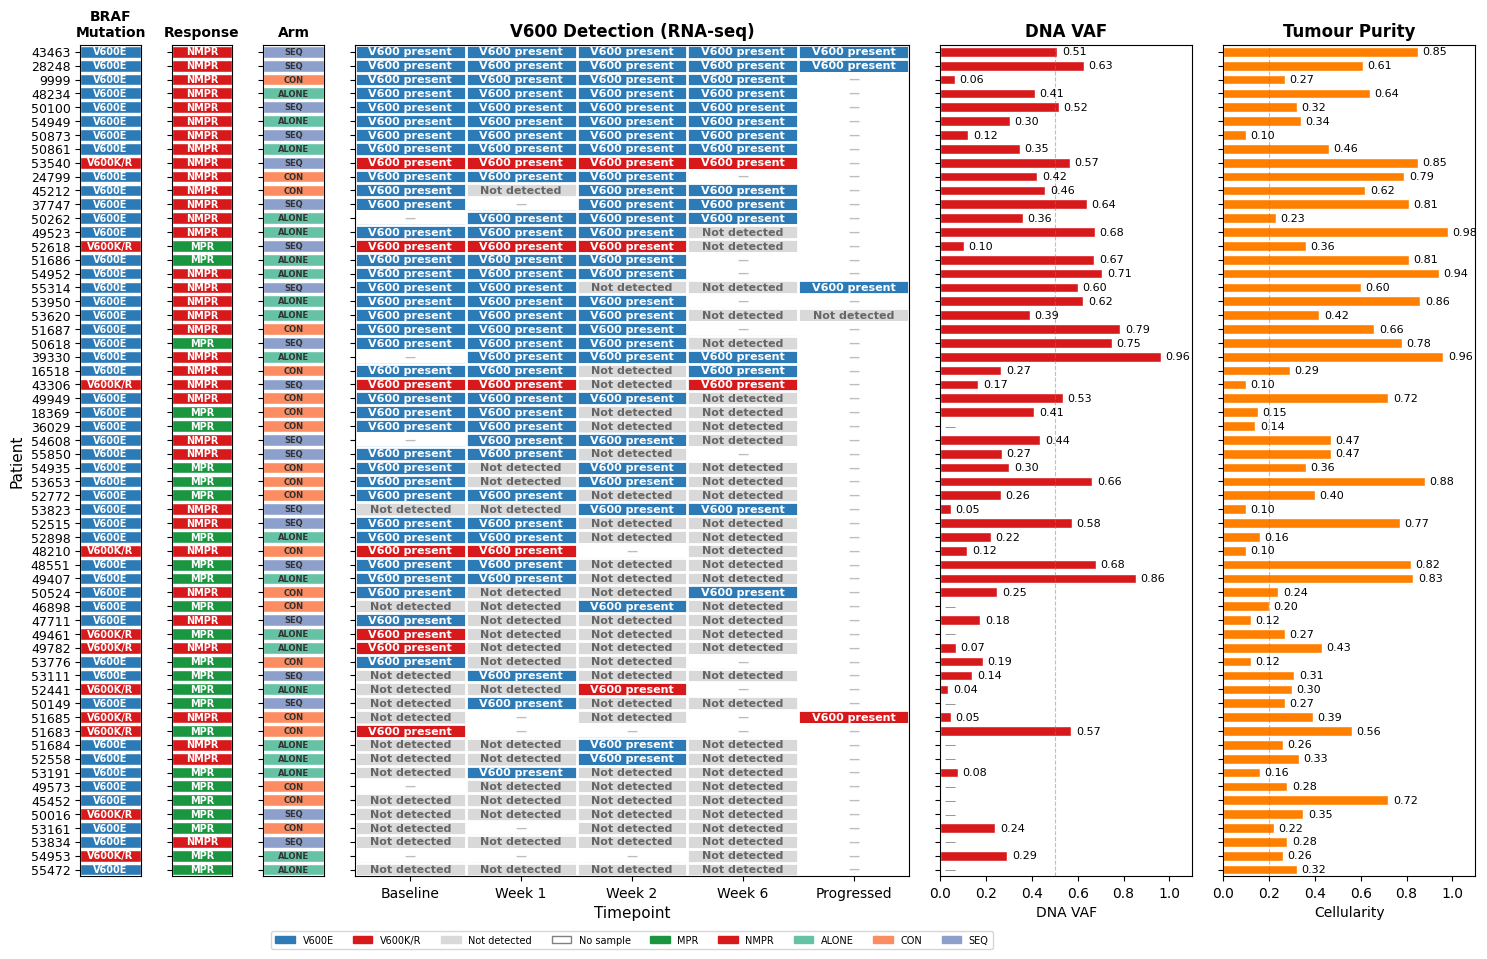

In [ ]:
# --- Load data ---
rna = v600_df.copy()
braf_status = pd.read_csv("braf_status.csv")

# --- Clean patient ID ---
rna['PATIENT'] = rna['PATIENT'].astype(str).str.extract(r'(\d+)').astype(int)

# --- Merge clinical metadata ---
meta = rna_meta
meta["MelPin"] = meta["MelPin"].astype(str).str.replace(r"_S\d+$", "", regex=True).astype(int)
patient_meta = meta.drop_duplicates(subset="MelPin").set_index("MelPin")

response_map = {1: "pCR", 2: "npCR", 3: "pPR", 4: "pNR"}
patient_meta["Response"] = patient_meta["path.response..1.pCR.2.npCR.3.pPR.4.pNR."].map(response_map)

mpr_map = {1: "MPR", 0: "NMPR"}
patient_meta["MPR"] = patient_meta["Major.Path.Response..pCR.npCR.1.pPR.pNR.0."].map(mpr_map)

# ###### binary status col #########
def assign_status(row):
    if row['V600_TYPE'] == 'V600E':
        return 2
    elif row['V600_TYPE'] in ('V600K', 'V600R'):
        return 3
    elif row['V600_TYPE'] == 'WT':
        return 1
    else:
        return 0

rna['status'] = rna.apply(assign_status, axis=1)

# Timepoint order
tp_order = ['Baseline', 'Week 1', 'Week 2', 'Week 6', 'Progressed']
rna['TIMEPOINT'] = pd.Categorical(rna['TIMEPOINT'], categories=tp_order, ordered=True)

# pivot here - one row per patient 
heatmap_df = rna.pivot_table(
    index='PATIENT',
    columns='TIMEPOINT',
    values='status',
    aggfunc='max'
)
heatmap_df = heatmap_df.reindex(columns=tp_order)
heatmap_df = heatmap_df.fillna(0).astype(int)

# --- Sort by number of V600-present timepoints (descending) ---
heatmap_df['v600_count'] = (heatmap_df >= 2).sum(axis=1)
heatmap_df = heatmap_df.sort_values('v600_count', ascending=False)
heatmap_df = heatmap_df.drop(columns='v600_count')

# --- DNA VAF & Cellularity ---
dna_meta['patient_id'] = dna_meta['melpin'].str.extract(r'(\d+)').astype(int)
dna_dedup = dna_meta.drop_duplicates('patient_id').set_index('patient_id')
dna_vaf_aligned = dna_dedup['braf_v600_AF'].reindex(heatmap_df.index)
cellularity_aligned = dna_dedup['cellularity'].reindex(heatmap_df.index)

# --- BRAF mutation type ---
braf_status['melpin'] = braf_status['melpin'].astype(int)
braf_type = braf_status.drop_duplicates('melpin').set_index('melpin')['BRAF_status']
braf_type_aligned = braf_type.reindex(heatmap_df.index).fillna('Unknown')

# --- Clinical metadata aligned ---
mpr_aligned = patient_meta['MPR'].reindex(heatmap_df.index)
arm_aligned = patient_meta['ARM'].reindex(heatmap_df.index)

# --- Color maps ---
braf_color_map = {
    'V600E': '#2c7bb6',
    'V600K/R': '#d7191c',
    'WT': '#d9d9d9',
    'Unknown': '#f0f0f0',
}

mpr_color_map = {
    'MPR': '#1a9641',
    'NMPR': '#d7191c',
}

arm_colors = plt.cm.Set2.colors
unique_arms = [a for a in arm_aligned.dropna().unique()]
arm_color_map = {arm: arm_colors[i % len(arm_colors)] for i, arm in enumerate(sorted(unique_arms))}

# --- Plot ---
n_patients = len(heatmap_df)
fig, (ax_type, ax_mpr, ax_arm, ax_heat, ax_vaf, ax_cell) = plt.subplots(
    1, 6,
    figsize=(18, max(n_patients * 0.18, 5)),
    width_ratios=[0.6, 0.6, 0.6, 5.5, 2.5, 2.5],
    sharey=True,
    gridspec_kw={'wspace': 0.15}
)
# --- BRAF Mutation Type panel ---
for i, (pat, btype) in enumerate(braf_type_aligned.items()):
    color = braf_color_map.get(btype, '#f0f0f0')
    ax_type.barh(i, 1, color=color, height=0.85, edgecolor='white')
    ax_type.text(0.5, i, btype, ha='center', va='center',
                 fontsize=7, fontweight='bold',
                 color='white' if btype in ['V600E', 'V600K/R'] else '#666666')

ax_type.set_xlim(0, 1)
ax_type.set_xticks([])
ax_type.set_yticks(range(n_patients))
ax_type.set_yticklabels(heatmap_df.index, fontsize=9)
ax_type.set_ylabel('Patient', fontsize=11)
ax_type.set_title('BRAF\nMutation', fontsize=10, fontweight='bold')

# --- MPR panel ---
for i, (pat, mpr) in enumerate(mpr_aligned.items()):
    color = mpr_color_map.get(mpr, '#f0f0f0')
    ax_mpr.barh(i, 1, color=color, height=0.85, edgecolor='white')
    label = mpr if pd.notna(mpr) else '—'
    ax_mpr.text(0.5, i, label, ha='center', va='center',
                fontsize=7, fontweight='bold',
                color='white' if mpr in ['MPR', 'NMPR'] else '#666666')

ax_mpr.set_xlim(0, 1)
ax_mpr.set_xticks([])
ax_mpr.set_title('Response', fontsize=10, fontweight='bold')

# --- ARM panel ---
for i, (pat, arm) in enumerate(arm_aligned.items()):
    color = arm_color_map.get(arm, '#f0f0f0')
    ax_arm.barh(i, 1, color=color, height=0.85, edgecolor='white')
    label = arm if pd.notna(arm) else '—'
    ax_arm.text(0.5, i, label, ha='center', va='center',
                fontsize=6, fontweight='bold', color='#333333')

ax_arm.set_xlim(0, 1)
ax_arm.set_xticks([])
ax_arm.set_title('Arm', fontsize=10, fontweight='bold')

# --- Heatmap ---
cmap = mcolors.ListedColormap(['#ffffff', '#d9d9d9', '#2c7bb6', '#d7191c'])
bounds = [-0.5, 0.5, 1.5, 2.5, 3.5]
norm = mcolors.BoundaryNorm(bounds, cmap.N)
ax_heat.imshow(heatmap_df.values, cmap=cmap, norm=norm, aspect='auto')

status_labels = {0: '—', 1: 'Not detected', 2: 'V600 present', 3: 'V600 present'}
status_colors = {0: '#bdbdbd', 1: '#666666', 2: 'white', 3: 'white'}
for i in range(n_patients):
    for j in range(len(tp_order)):
        val = heatmap_df.iloc[i, j]
        ax_heat.text(j, i, status_labels[val], ha='center', va='center',
                     fontsize=8, color=status_colors[val], fontweight='bold')

ax_heat.set_xticks(range(len(tp_order)))
ax_heat.set_xticklabels(tp_order, fontsize=10)
ax_heat.set_xlabel('Timepoint', fontsize=11)
ax_heat.set_title('V600 Detection (RNA-seq)', fontsize=12, fontweight='bold')

for i in range(n_patients + 1):
    ax_heat.axhline(i - 0.5, color='white', linewidth=2)
for j in range(len(tp_order) + 1):
    ax_heat.axvline(j - 0.5, color='white', linewidth=2)

# --- Legend ---
legend_patches = [
    mpatches.Patch(color='#2c7bb6', label='V600E'),
    mpatches.Patch(color='#d7191c', label='V600K/R'),
    mpatches.Patch(color='#d9d9d9', edgecolor='grey', label='Not detected'),
    mpatches.Patch(facecolor='#ffffff', edgecolor='grey', label='No sample'),
    mpatches.Patch(color='#1a9641', label='MPR'),
    mpatches.Patch(color=mpr_color_map['NMPR'], label='NMPR'),
]
# Add ARM legend entries
for arm, color in sorted(arm_color_map.items()):
    legend_patches.append(mpatches.Patch(color=color, label=arm))

ax_heat.legend(handles=legend_patches, loc='upper center',
               bbox_to_anchor=(0.5, -0.06), ncol=len(legend_patches), fontsize=7)

# --- DNA VAF barplot ---
colors_vaf = ['#d7191c' if pd.notna(v) and v > 0 else '#e0e0e0'
              for v in dna_vaf_aligned.values]
ax_vaf.barh(range(n_patients), dna_vaf_aligned.fillna(0).values,
            color=colors_vaf, height=0.7, edgecolor='white')
for i, v in enumerate(dna_vaf_aligned.values):
    if pd.notna(v) and v > 0:
        ax_vaf.text(v + 0.02, i, f'{v:.2f}', va='center', fontsize=8)
    else:
        ax_vaf.text(0.02, i, '—', va='center', fontsize=8, color='grey')
ax_vaf.set_xlabel('DNA VAF', fontsize=10)
ax_vaf.set_xlim(0, 1.1)
ax_vaf.set_title('DNA VAF', fontsize=12, fontweight='bold')
ax_vaf.axvline(0.5, color='grey', linestyle='--', linewidth=0.8, alpha=0.5)

###########
colours_cell = ['#ff7f00' if pd.notna(v) and v > 0 else '#e0e0e0'
               for v in cellularity_aligned.values]
ax_cell.barh(range(n_patients), cellularity_aligned.fillna(0).values,
             color=colours_cell, height=0.7, edgecolor='white')
for i, v in enumerate(cellularity_aligned.values):
    if pd.notna(v) and v > 0:
        ax_cell.text(v + 0.02, i, f'{v:.2f}', va='center', fontsize=8)
    else:
        ax_cell.text(0.02, i, '—', va='center', fontsize=8, color='grey')
ax_cell.set_xlabel('Cellularity', fontsize=10)
ax_cell.set_xlim(0, 1.1)
ax_cell.set_title('Tumour Purity', fontsize=12, fontweight='bold')
ax_cell.axvline(0.2, color='grey', linestyle='--', linewidth=0.8, alpha=0.5)

plt.tight_layout()
plt.savefig('plots/braf_v600_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

     PATIENT   TIMEPOINT   REF   ALT V600_TYPE   AF     QUAL FILTER  \
0      16518    Baseline     A     T     V600E  0.5   133.64   PASS   
1      18369    Baseline     A     T     V600E  0.5   744.64   PASS   
2      24799    Baseline     A     T     V600E  0.5   519.64   PASS   
3      28248    Baseline     A     T     V600E  0.5   619.64   PASS   
4      36029    Baseline     A     T     V600E  0.5   179.64   PASS   
..       ...         ...   ...   ...       ...  ...      ...    ...   
217    28248  Progressed     A     T     V600E  0.5   920.64   PASS   
218    43463  Progressed     A     T     V600E  0.5   946.64   PASS   
219    51685  Progressed    AC    TT     V600K  0.5  1246.64   PASS   
220    53620  Progressed  None  None        WT  NaN     None   None   
221    55314  Progressed     A     T     V600E  0.5  2520.64   PASS   

             POS Response    AnyResponse    ARM  status  V600_positive  
0    140753336.0      pNR  Non-responder    CON       2           True  
1

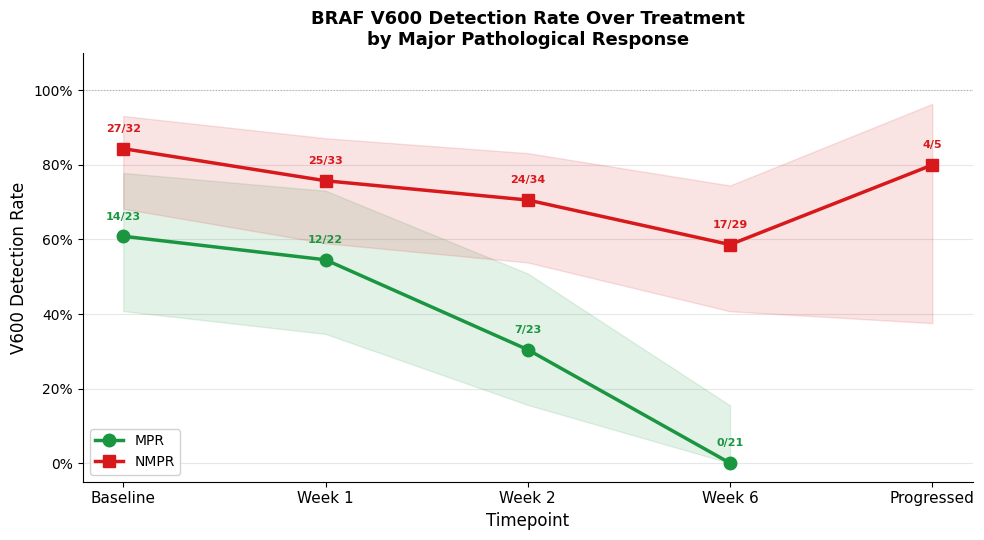

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# --- Prep data ---
plot_df = rna.copy()
plot_df = plot_df[plot_df['TIMEPOINT'] != 'Unknown']

# Merge MPR status
plot_df = plot_df.merge(
    patient_meta[['MPR']].reset_index().rename(columns={'MelPin': 'PATIENT'}),
    on='PATIENT',
    how='left'
)

plot_df = plot_df [[c for c in plot_df.columns if not c.endswith(("_x", "_y"))]]

# Flag V600-positive (E, K, or R)
plot_df['V600_positive'] = plot_df['V600_TYPE'].isin(['V600E', 'V600K', 'V600R'])

print(plot_df)
# Only keep patients with known MPR status
plot_df['MPR_group'] = plot_df['Response'].map({
    'pCR': 'MPR', 'npCR': 'MPR',
    'pPR': 'NMPR', 'pNR': 'NMPR'
})
plot_df = plot_df[plot_df['MPR_group'].isin(['MPR', 'NMPR'])]

tp_order = ['Baseline', 'Week 1', 'Week 2', 'Week 6', 'Progressed']

# Calculate detection rate per timepoint per response group
rates = []
for mpr in ['MPR', 'NMPR']:
    for tp in tp_order:
        sub = plot_df[(plot_df['MPR_group'] == mpr) & (plot_df['TIMEPOINT'] == tp)]
        n_total = len(sub)
        if n_total == 0:
            continue
        n_pos = sub['V600_positive'].sum()
        rate = n_pos / n_total
        # Wilson confidence interval
        z = 1.96
        denom = 1 + z**2 / n_total
        centre = (rate + z**2 / (2 * n_total)) / denom
        margin = z * np.sqrt((rate * (1 - rate) + z**2 / (4 * n_total)) / n_total) / denom
        rates.append({
            'MPR': mpr,
            'TIMEPOINT': tp,
            'rate': rate,
            'ci_low': max(0, centre - margin),
            'ci_high': min(1, centre + margin),
            'n_pos': int(n_pos),
            'n_total': int(n_total),
        })

rates_df = pd.DataFrame(rates)
print(rates_df)
rates_df['TIMEPOINT'] = pd.Categorical(rates_df['TIMEPOINT'], categories=tp_order, ordered=True)
rates_df = rates_df.sort_values('TIMEPOINT')

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 5.5))

colors = {'MPR': '#1a9641', 'NMPR': '#d7191c'}
markers = {'MPR': 'o', 'NMPR': 's'}
labels = {'MPR': 'MPR', 'NMPR': 'NMPR'}

for mpr in ['MPR', 'NMPR']:
    sub = rates_df[rates_df['MPR'] == mpr]
    x = np.arange(len(sub))
    ax.plot(x, sub['rate'].values, marker=markers[mpr], color=colors[mpr],
            linewidth=2.5, markersize=9, label=labels[mpr], zorder=3)
    ax.fill_between(x, sub['ci_low'].values, sub['ci_high'].values,
                    color=colors[mpr], alpha=0.12, zorder=2)
    # Annotate n/N
    for xi, row in zip(x, sub.itertuples()):
        ax.annotate(f'{row.n_pos}/{row.n_total}',
                    (xi, row.rate), textcoords='offset points',
                    xytext=(0, 12), ha='center', fontsize=8, color=colors[mpr],
                    fontweight='bold')

ax.set_xticks(np.arange(len(tp_order)))
ax.set_xticklabels(tp_order, fontsize=11)
ax.set_ylabel('V600 Detection Rate', fontsize=12)
ax.set_xlabel('Timepoint', fontsize=12)
ax.set_title('BRAF V600 Detection Rate Over Treatment\nby Major Pathological Response',
             fontsize=13, fontweight='bold')
ax.set_ylim(-0.05, 1.1)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.axhline(1.0, color='grey', linestyle=':', linewidth=0.8, alpha=0.5)
ax.legend(loc='lower left', fontsize=10, framealpha=0.9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('plots/v600_detection_rate_by_response.png', dpi=300, bbox_inches='tight')
plt.show()